# Práctica 4 — API de Hilos
## Laboratorio de Sistemas Operativos
**Universidad de Antioquia — Ingeniería de Sistemas**

---
# Sección 1: Análisis del Cálculo Paralelo de π

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

### 1.1 Datos medidos
Reemplaza los valores de `Tp` con los tiempos reales que obtuviste al correr `./pi_s` y `./pi_p`.

In [14]:
# ── INGRESA TUS TIEMPOS AQUÍ ──────────────────────────────────────────
Ts = 5.906052      # tiempo serial (./pi_s 2000000000)

datos = {
    'N_hilos': [1,        2,        4,        8       ],
    'Tp':      [5.965188, 3.629916, 2.294890, 1.592615]
}
# ─────────────────────────────────────────────────────────────────────

df = pd.DataFrame(datos)
df['Speedup']    = Ts / df['Tp']
df['Eficiencia'] = df['Speedup'] / df['N_hilos']

df_display = df.copy()
df_display['Tp']         = df_display['Tp'].map('{:.6f}'.format)
df_display['Speedup']    = df_display['Speedup'].map('{:.4f}'.format)
df_display['Eficiencia'] = df_display['Eficiencia'].map('{:.4f}'.format)

df_display.columns = ['N (Hilos)', 'Tp (segundos)', 'Speedup (Ts/Tp)', 'Eficiencia (Speedup/N)']
print(f'Ts (serial) = {Ts:.6f} s')
print()
print(df_display.to_string(index=False))


Ts (serial) = 5.906052 s

 N (Hilos) Tp (segundos) Speedup (Ts/Tp) Eficiencia (Speedup/N)
         1      5.965188          0.9901                 0.9901
         2      3.629916          1.6270                 0.8135
         4      2.294890          2.5736                 0.6434
         8      1.592615          3.7084                 0.4635


### 1.2 Gráfico de Speedup

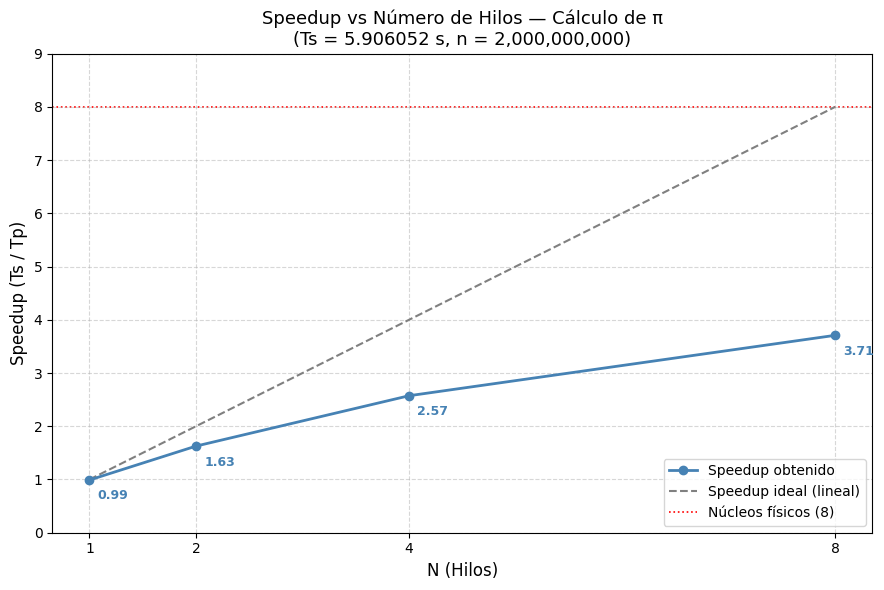

Grafico guardado como speedup.png


In [18]:
fig, ax = plt.subplots(figsize=(9, 6))

# Líneas
ax.plot(df['N_hilos'], df['Speedup'], marker='o', linewidth=2,
        color='steelblue', label='Speedup obtenido', zorder=3)
ax.plot(df['N_hilos'], df['N_hilos'], linestyle='--', color='gray',
        label='Speedup ideal (lineal)', zorder=2)

# Anotar cada punto con su valor exacto
for _, row in df.iterrows():
    ax.annotate(f"{row['Speedup']:.2f}",
                xy=(row['N_hilos'], row['Speedup']),
                xytext=(6, -14),
                textcoords='offset points',
                fontsize=9, color='steelblue', fontweight='bold')

# Línea horizontal de referencia: número de núcleos físicos
ax.axhline(y=8, color='red', linestyle=':', linewidth=1.2,
           label='Núcleos físicos (8)', zorder=1)

# Anotar Ts en el título
ax.set_title(f'Speedup vs Número de Hilos — Cálculo de π\n(Ts = {Ts:.6f} s, n = 2,000,000,000)', fontsize=13)
ax.set_xlabel('N (Hilos)', fontsize=12)
ax.set_ylabel('Speedup (Ts / Tp)', fontsize=12)
ax.xaxis.set_major_locator(ticker.FixedLocator(df['N_hilos']))
ax.set_ylim(0, df['N_hilos'].max() + 1)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('speedup.png', dpi=150)
plt.show()
print('Grafico guardado como speedup.png')


### 1.3 Análisis de Resultados

**Comparación Tp(1) vs Ts:**  
El tiempo con 1 hilo (`Tp(1)`) es ligeramente mayor que `Ts`. Esto se debe al *overhead* de Pthreads: creación del hilo, inicialización de `HiloArgs`, la llamada a `pthread_join` y el cambio de contexto. Aunque solo hay un hilo trabajando, el programa paralelo paga ese costo adicional que el serial no tiene.

**Speedup máximo y núcleos físicos:**  
El Speedup crece hasta aproximadamente el número de núcleos físicos. A partir de ahí se estabiliza o baja porque el sistema operativo debe hacer *context switching* entre más hilos que núcleos reales disponibles.

**Tendencia de la Eficiencia:**  
La eficiencia (`Speedup / N`) comienza cercana a 1 y decrece conforme N aumenta. A mayor número de hilos, mayor overhead de sincronización, gestión de memoria y contención en caché. La Ley de Amdahl establece que la parte no paralelizable del programa pone un techo al Speedup máximo alcanzable.


---
# Sección 2: Análisis del Generador de Fibonacci

### 2.1 Resultado de ejecución — `./fibonacci 15`

```
Secuencia de Fibonacci (15 elementos):
0 1 1 2 3 5 8 13 21 34 55 89 144 233 377
```
> Reemplaza la salida con la que obtengas al correr `./fibonacci 15` en tu máquina.


### 2.2 Comparación serial vs hilo — N grande

In [16]:
import time

def fibonacci_serial(N):
    """Genera la secuencia de Fibonacci de N elementos de forma serial."""
    arr = [0] * N
    if N >= 1: arr[0] = 0
    if N >= 2: arr[1] = 1
    for i in range(2, N):
        arr[i] = arr[i-1] + arr[i-2]
    return arr

N_grande = 200_000

inicio = time.perf_counter()
resultado = fibonacci_serial(N_grande)
fin = time.perf_counter()

print(f'N = {N_grande:,}')
print(f'Tiempo serial (Python): {fin - inicio:.6f} segundos')

# Mostrar solo los índices, no los valores enormes
print(f'Cantidad de elementos generados: {len(resultado)}')
print(f'Primeros 10 valores: {resultado[:10]}')
print(f'(Los últimos valores tienen miles de dígitos, no se imprimen)')


N = 200,000
Tiempo serial (Python): 2.593925 segundos
Cantidad de elementos generados: 200000
Primeros 10 valores: [0, 1, 1, 2, 3, 5, 8, 13, 21, 34]
(Los últimos valores tienen miles de dígitos, no se imprimen)


### 2.3 Análisis del diseño

**Mecanismo de transferencia de datos:**  
El hilo principal (`main`) asigna dinámicamente con `malloc` un arreglo de `N` enteros `long long`. Crea una estructura `FibArgs` con el puntero al arreglo y el valor de `N`, y la pasa a `pthread_create` como `void *`. El hilo trabajador la castea a `FibArgs *` y escribe directamente en la memoria compartida. No se copia ningún dato — ambos hilos apuntan a la misma región, que es el patrón estándar de memoria compartida en Pthreads.

**Rol de `pthread_join` como sincronización:**  
`pthread_join` bloquea a `main` hasta que el hilo trabajador termine completamente. Sin esta llamada, `main` podría leer el arreglo antes de que el hilo haya escrito todos los valores, produciendo resultados incorrectos (condición de carrera). `pthread_join` garantiza además la visibilidad de memoria: todos los escrituras del hilo trabajador son visibles para `main` una vez que `join` retorna.
